깊이 맵 크기: (480, 640)
값 범위: [0.00, 1.00]
가까운 물체 (높은 값): 0.90
먼 배경 (skwdms rkqt): 0.10

 절대 깊이 반환 (scale=10.0m)
가까운 물체: 9.0m
먼 배경: 1.041667m


/tmp/ipykernel_1105028/148766266.py:40: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1105028/148766266.py:40: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1105028/148766266.py:40: UserWarning: Glyph 44618 (\N{HANGUL SYLLABLE GIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1105028/148766266.py:40: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1105028/148766266.py:40: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1105028/148766266.py:40: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1105028/148766266.py:40: UserWarning: Glyph 52972 (\N{HANGUL SYLLABLE KEOL}) missing from font(s) DejaVu San


 시각화 저장: outputs/depth_basics.png

Relative vs Metric Depth 비교

    장면: 사람(2.5m), 자동차(8m), 건물(25m)


    Relative Depth:
      사람: 0.92 (가장 가까움)
      자동차: 0.68
      건물: 0.12 (가장 멀리)
      → 순서 정보만 제공


    Metric Depth:
      사람: 2.5m (정확한 거리)
      자동차: 8.0m
      건물: 25.0m
      → 실제 거리 정보 제공


    용도별 선택:
      장애물 유무 판단 → Relative (충분)
      정확한 정지 거리 → Metric (필요)
      SLAM 스케일 복구 → Metric (필수)
    


/workspace/study/physical-ai-study/Studies/Phase 3/week7/.venv-week7/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/study/physical-ai-study/Studies/Phase 3/week7/.venv-week7/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/study/physical-ai-study/Studies/Phase 3/week7/.venv-week7/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44618 (\N{HANGUL SYLLABLE GIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/study/physical-ai-study/Studies/Phase 3/week7/.venv-week7/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

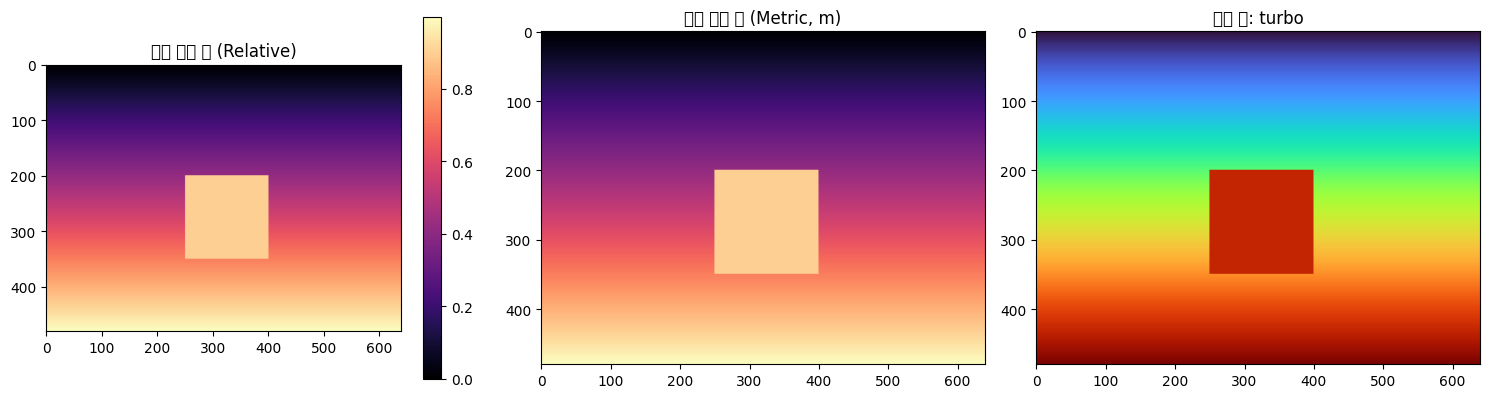

In [6]:
import os 
import numpy as np
import matplotlib.pyplot as plt

def explore_depth_map():
    h, w = 480, 640

    relative_depth = np.zeros((h, w), dtype=np.float32)

    for y in range(h):
        relative_depth[y, :] = y / h

    relative_depth[200:350, 250:400] = 0.9

    print(f"깊이 맵 크기: {relative_depth.shape}")
    print(f"값 범위: [{relative_depth.min():.2f}, {relative_depth.max():.2f}]")
    print(f"가까운 물체 (높은 값): {relative_depth[275, 325]:.2f}")
    print(f"먼 배경 (skwdms rkqt): {relative_depth[50, 320]:.2f}")

    scale = 10.0
    metric_depth = relative_depth * scale

    print(f"\n 절대 깊이 반환 (scale={scale}m)")
    print(f"가까운 물체: {metric_depth[275, 325]:.1f}m")
    print(f"먼 배경: {metric_depth[50, 320]:1f}m")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(relative_depth, cmap="magma")
    axes[0].set_title("Relative Depth Map")
    axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])

    axes[1].imshow(metric_depth, cmap="magma")
    axes[1].set_title("Metric Depth Map (m)")

    for ax, cmap in zip([axes[2]], ["turbo"]):
        ax.imshow(relative_depth, cmap=cmap)
        ax.set_title(f"Colormap: {cmap}")

    plt.tight_layout()
    os.makedirs("outputs", exist_ok=True)
    plt.savefig("outputs/depth_basics.png", dpi=100)
    print("\n 시각화 저장: outputs/depth_basics.png")

def compare_depth_representations():
    print("\n" + "=" * 40)
    print("Relative vs Metric Depth 비교")
    print("=" * 40)

    print("""
    장면: 사람(2.5m), 자동차(8m), 건물(25m)


    Relative Depth:
      사람: 0.92 (가장 가까움)
      자동차: 0.68
      건물: 0.12 (가장 멀리)
      → 순서 정보만 제공


    Metric Depth:
      사람: 2.5m (정확한 거리)
      자동차: 8.0m
      건물: 25.0m
      → 실제 거리 정보 제공


    용도별 선택:
      장애물 유무 판단 → Relative (충분)
      정확한 정지 거리 → Metric (필요)
      SLAM 스케일 복구 → Metric (필수)
    """)

if __name__ == "__main__":
    explore_depth_map()
    compare_depth_representations()


In [11]:
import torch

def explore_midas():
    model_types = {
        "MiDaS_small": "경량 모델 (모바일용)",
        "DPT_Hybrid": "DPT 하이브리드 (CNN + ViT)",
        "DPT_Large": "DPT 대형 (ViT-Large)",
    }

    for model_type, desc in model_types.items():
        print(f"\n 모델: {model_type} - {desc}")
        try:
            model = torch.hub.load("intel-isl/MiDaS", model_type, trust_repo=True)
            model.eval()

            total_params = sum(p.numel() for p in model.parameters())
            trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

            print(f"총 파라미터: {total_params / 1e6:.1f}M")
            print(f"학습 가능 파라미터: {trainable_params / 1e6:.1f}M")

            dummy = torch.randn(1, 3, 384, 384)

            with torch.no_grad():
                output = model(dummy)
            print(f"입력: {list(dummy.shape)}")
            print(f"출력: {list(output.shape)}")

        except Exception as e:
            print(f"로드 실패: {e}")
            print(f"(인터넷 연결 필요)")

if __name__ == "__main__":
    explore_midas()


 모델: MiDaS_small - 경량 모델 (모바일용)
Loading weights:  None


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


총 파라미터: 21.3M
학습 가능 파라미터: 21.3M
입력: [1, 3, 384, 384]
출력: [1, 384, 384]

 모델: DPT_Hybrid - DPT 하이브리드 (CNN + ViT)


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


총 파라미터: 123.1M
학습 가능 파라미터: 123.1M
입력: [1, 3, 384, 384]
출력: [1, 384, 384]

 모델: DPT_Large - DPT 대형 (ViT-Large)


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt


100%|██████████| 1.28G/1.28G [00:26<00:00, 52.9MB/s]


총 파라미터: 344.1M
학습 가능 파라미터: 344.1M
입력: [1, 3, 384, 384]
출력: [1, 384, 384]


In [12]:
from transformers import AutoModelForDepthEstimation
from transformers import AutoImageProcessor
import torch

def explore_depth_anything():
    models = {
        "depth-anything/Depth-Anything-V2-Small-hf": "ViT-S(Small)",
        "depth-anything/Depth-Anything-V2-Base-hf": "ViT-B(Base)",
    }

    for model_name, desc in models.items():
        print(f"\n 모델: {desc}")
        print(f"경로: {model_name}")

        try:
            model = AutoModelForDepthEstimation.from_pretrained(model_name)
            model.eval()

            total_params = sum(p.numel() for p in model.parameters())
            print(f"총 파라미터: {total_params / 1e6:.1f}M")

            print("구조:")
            for name, module in model.named_children():
                num_params = sum(p.numel() for p in module.parameters())
                print(f"{name}: {num_params / 1e6:.1f}M 파라미터")

            dummy = torch.randn(1, 3, 518, 518)

            with torch.no_grad():
                output = model(dummy)

            depth = output.predicted_depth
            print(f"입력: {list(dummy.shape)}")
            print(f"출력: {list(depth.shape)}")
            print(f"깊이 범위: [{depth.min():.3f}, {depth.max():.3f}]")

        except Exception as e:
            print(f"로드 실패: {e}")
            print("(인터넷 연결 및 transformers 설치 필요)")

def analyze_vit_structure():
    print("""
    Depth Anything의 ViT 구조:


    1. Patch Embedding
       이미지 (3, 518, 518) → 패치 (N, 768)
       패치 크기: 14x14
       패치 수: (518/14)^2 = 37^2 = 1369


    2. Transformer Encoder
       Multi-Head Self-Attention × 12 (Small)
       → 각 패치가 다른 모든 패치와 관계 학습
       → 전역 컨텍스트 이해


    3. Decoder (DPT Head)
       Multi-scale Feature 결합
       → 1/4, 1/8, 1/16, 1/32 해상도 특징
       → 점진적 업샘플링으로 밀집 깊이맵 생성


    4. 출력
       (1, H, W) 깊이맵
       → 입력과 동일한 해상도
    """)


if __name__ == "__main__":
    explore_depth_anything()
    analyze_vit_structure()


 모델: ViT-S(Small)
경로: depth-anything/Depth-Anything-V2-Small-hf


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 15808.65it/s]


총 파라미터: 24.8M
구조:
backbone: 22.1M 파라미터
neck: 2.7M 파라미터
head: 0.0M 파라미터
입력: [1, 3, 518, 518]
출력: [1, 518, 518]
깊이 범위: [2.140, 4.137]

 모델: ViT-B(Base)
경로: depth-anything/Depth-Anything-V2-Base-hf


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 13525.60it/s]


총 파라미터: 97.5M
구조:
backbone: 86.6M 파라미터
neck: 10.8M 파라미터
head: 0.1M 파라미터
입력: [1, 3, 518, 518]
출력: [1, 518, 518]
깊이 범위: [2.037, 7.701]

    Depth Anything의 ViT 구조:


    1. Patch Embedding
       이미지 (3, 518, 518) → 패치 (N, 768)
       패치 크기: 14x14
       패치 수: (518/14)^2 = 37^2 = 1369


    2. Transformer Encoder
       Multi-Head Self-Attention × 12 (Small)
       → 각 패치가 다른 모든 패치와 관계 학습
       → 전역 컨텍스트 이해


    3. Decoder (DPT Head)
       Multi-scale Feature 결합
       → 1/4, 1/8, 1/16, 1/32 해상도 특징
       → 점진적 업샘플링으로 밀집 깊이맵 생성


    4. 출력
       (1, H, W) 깊이맵
       → 입력과 동일한 해상도
    


In [13]:
def compare_models():
    print("""
    +--------------+--------------+--------------+--------------+
    | 항목 | MiDaS v3.1 | DPT-Large | Depth Any-S |
    +--------------+--------------+--------------+--------------+
    | 연도 | 2022 | 2021 | 2024 |
    | Backbone | BEiT/Swin | ViT-Large | ViT-Small |
    | 파라미터 | ~345M | ~343M | ~24.8M |
    | 학습 데이터 | 라벨 12종 | 라벨 1.2M | 라벨+비라벨 |
    | | | | 63.5M |
    | Zero-shot | 좋음 | 좋음 | 매우 우수 |
    | 속도 (A100) | ~40ms | ~45ms | ~12ms |
    | Jetson 추론 | ~200ms | ~350ms | ~50ms |
    | 출력 타입 | Relative | Relative | Relative |
    | 실시간 가능 | 어려움 | 불가능 | 가능 (FP16) |
    +--------------+--------------+--------------+--------------+
    """)


    print("\n 용도별 추천:")
    print("+----------------------+------------------+")
    print("| 용도 | 추천 모델 |")
    print("+----------------------+------------------+")
    print("| Jetson 실시간 추론 | Depth Anything-S |")
    print("| 서버 고정밀 추론 | Depth Anything-L |")
    print("| 연구/실험용 | DPT-Large |")
    print("| 레거시 호환 | MiDaS v3.1 |")
    print("+----------------------+------------------+")

def compare_learning_methods():
    print("""
    +------------------+--------------+--------------+--------------+
    | 항목 | Supervised |Self-supervised| Zero-shot |
    +------------------+--------------+--------------+--------------+
    | GT 깊이 필요 | 필요 | 불필요 | 혼합 |
    | 학습 데이터 | 적음 (~1M) | 중간 | 대규모 |
    | | | (동영상) | (60M+) |
    | 일반화 능력 | 약함 | 보통 | 매우 강함 |
    | 정확도 | 높음 | 보통 | 높음 |
    | 대표 모델 | AdaBins | Monodepth2 | Depth Any. |
    | 특징 | 환경 특화 | 비디오 활용 | 범용적 |
    +------------------+--------------+--------------+--------------+
    """)


if __name__ == "__main__":
    compare_models()
    compare_learning_methods()


    +--------------+--------------+--------------+--------------+
    | 항목 | MiDaS v3.1 | DPT-Large | Depth Any-S |
    +--------------+--------------+--------------+--------------+
    | 연도 | 2022 | 2021 | 2024 |
    | Backbone | BEiT/Swin | ViT-Large | ViT-Small |
    | 파라미터 | ~345M | ~343M | ~24.8M |
    | 학습 데이터 | 라벨 12종 | 라벨 1.2M | 라벨+비라벨 |
    | | | | 63.5M |
    | Zero-shot | 좋음 | 좋음 | 매우 우수 |
    | 속도 (A100) | ~40ms | ~45ms | ~12ms |
    | Jetson 추론 | ~200ms | ~350ms | ~50ms |
    | 출력 타입 | Relative | Relative | Relative |
    | 실시간 가능 | 어려움 | 불가능 | 가능 (FP16) |
    +--------------+--------------+--------------+--------------+
    

 용도별 추천:
+----------------------+------------------+
| 용도 | 추천 모델 |
+----------------------+------------------+
| Jetson 실시간 추론 | Depth Anything-S |
| 서버 고정밀 추론 | Depth Anything-L |
| 연구/실험용 | DPT-Large |
| 레거시 호환 | MiDaS v3.1 |
+----------------------+------------------+

    +------------------+--------------+--------------+--------------+
    | 항